# PRCP-1014: Vaccine Prediction

## Objective

The goal of this project is to predict how likely survey respondents were to receive two vaccines: the H1N1 flu vaccine and the seasonal flu vaccine. The data comes from the National 2009 H1N1 Flu Survey, a US phone survey that recorded each respondent's background, opinions about flu risk and vaccines, and health-related behaviours.

The project description frames this as a multilabel problem. A respondent may have received neither vaccine, one of them, or both, so the two outcomes are not mutually exclusive categories. The required output is a probability for each vaccine rather than only a yes/no label.

The project description documents the features and their coding. Before any analysis decisions are made, I verify that documentation against the actual data files.

In [17]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Fixed seed so splits and models are reproducible across runs
RANDOM_STATE = 42

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Python:", sys.version.split()[0])
for lib in (np, pd, matplotlib, sns, sklearn):
    print(f"{lib.__name__}: {lib.__version__}")

Python: 3.13.15
numpy: 2.5.2
pandas: 3.0.2
matplotlib: 3.11.1
seaborn: 0.13.2
sklearn: 1.9.1


## Loading the supplied data

The project data comes as two files, `features.csv` and `labels.csv`, which are loaded with pandas from the folder where they are stored locally. If the notebook is run on another machine, the file paths in the next cell need to point to the location of these two files. Before analysing anything, I check how the two files relate to each other, since the features and targets need to be matched correctly for each respondent.

In [4]:
features = pd.read_csv(r"C:\Users\sahup\Downloads\Data\features.csv")
labels = pd.read_csv(r"C:\Users\sahup\Downloads\Data\labels.csv")

In [5]:
print("features:", features.shape)
print("labels:  ", labels.shape)

display(features.head(3))
display(labels.head(3))

features: (26707, 36)
labels:   (26707, 3)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo


,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0


In [6]:
shared_cols = sorted(set(features.columns) & set(labels.columns))
print("Columns in labels:", list(labels.columns))
print("Columns shared by both files:", shared_cols)

# For each shared column (a likely ID), check uniqueness, overlap and row alignment
for col in shared_cols:
    f_ids = features[col]
    l_ids = labels[col]
    print(f"\n'{col}'")
    print("  duplicates in features:", f_ids.duplicated().sum())
    print("  duplicates in labels:  ", l_ids.duplicated().sum())
    print("  values in both files:  ", len(set(f_ids) & set(l_ids)))
    print("  only in features:      ", len(set(f_ids) - set(l_ids)))
    print("  only in labels:        ", len(set(l_ids) - set(f_ids)))
    print("  same row order:        ", f_ids.reset_index(drop=True).equals(l_ids.reset_index(drop=True)))

Columns in labels: ['respondent_id', 'h1n1_vaccine', 'seasonal_vaccine']
Columns shared by both files: ['respondent_id']

'respondent_id'
  duplicates in features: 0
  duplicates in labels:   0
  values in both files:   26707
  only in features:       0
  only in labels:         0
  same row order:         True


### How the two files relate

`labels.csv` contains three columns: `respondent_id` and the two targets, `h1n1_vaccine` and `seasonal_vaccine`. The only column shared with `features.csv` is `respondent_id`.

I checked this ID before joining anything. It has no duplicates in either file, all 26,707 IDs appear in both files with none missing from either side, and the rows are stored in the same order. This means each respondent has exactly one feature row and one label row, so the files can be merged one-to-one on `respondent_id` without losing or duplicating anyone.

`respondent_id` is only an identifier, so I use it as the index and keep it out of the predictors.

In [7]:
# validate="one_to_one" makes pandas raise an error if the ID were ever duplicated
df = features.merge(labels, on="respondent_id", how="inner", validate="one_to_one")
df = df.set_index("respondent_id")

TARGETS = ["h1n1_vaccine", "seasonal_vaccine"]
FEATURES = [col for col in df.columns if col not in TARGETS]

print("Merged shape:", df.shape)
print("Number of feature columns:", len(FEATURES))

Merged shape: (26707, 37)
Number of feature columns: 35


In [8]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
display(overview)

,dtype,n_missing,pct_missing,n_unique
h1n1_concern,float64,92,0.34,4
h1n1_knowledge,float64,116,0.43,3
behavioral_antiviral_meds,float64,71,0.27,2
behavioral_avoidance,float64,208,0.78,2
behavioral_face_mask,float64,19,0.07,2
behavioral_wash_hands,float64,42,0.16,2
behavioral_large_gatherings,float64,87,0.33,2
behavioral_outside_home,float64,82,0.31,2
behavioral_touch_face,float64,128,0.48,2
doctor_recc_h1n1,float64,2160,8.09,2


In [10]:
# Show the distinct values of each column so they can be compared with the coding in the project document
for col in df.columns:
    values = sorted(df[col].dropna().unique().tolist(), key=str)
    shown = values if len(values) <= 15 else values[:15] + ["..."]
    print(f"{col} ({len(values)} unique): {shown}")

h1n1_concern (4 unique): [0.0, 1.0, 2.0, 3.0]
h1n1_knowledge (3 unique): [0.0, 1.0, 2.0]
behavioral_antiviral_meds (2 unique): [0.0, 1.0]
behavioral_avoidance (2 unique): [0.0, 1.0]
behavioral_face_mask (2 unique): [0.0, 1.0]
behavioral_wash_hands (2 unique): [0.0, 1.0]
behavioral_large_gatherings (2 unique): [0.0, 1.0]
behavioral_outside_home (2 unique): [0.0, 1.0]
behavioral_touch_face (2 unique): [0.0, 1.0]
doctor_recc_h1n1 (2 unique): [0.0, 1.0]
doctor_recc_seasonal (2 unique): [0.0, 1.0]
chronic_med_condition (2 unique): [0.0, 1.0]
child_under_6_months (2 unique): [0.0, 1.0]
health_worker (2 unique): [0.0, 1.0]
health_insurance (2 unique): [0.0, 1.0]
opinion_h1n1_vacc_effective (5 unique): [1.0, 2.0, 3.0, 4.0, 5.0]
opinion_h1n1_risk (5 unique): [1.0, 2.0, 3.0, 4.0, 5.0]
opinion_h1n1_sick_from_vacc (5 unique): [1.0, 2.0, 3.0, 4.0, 5.0]
opinion_seas_vacc_effective (5 unique): [1.0, 2.0, 3.0, 4.0, 5.0]
opinion_seas_risk (5 unique): [1.0, 2.0, 3.0, 4.0, 5.0]
opinion_seas_sick_from_vac

### Data understanding

The merged dataset has 26,707 respondents and 37 columns: 35 features and the two targets. This matches the project description (36 columns including `respondent_id`).

I compared the distinct values of every column with the coding in the project document, and they match. The binary features contain only 0 and 1, `h1n1_concern` runs from 0 to 3, `h1n1_knowledge` from 0 to 2, the six opinion questions from 1 to 5, and the household counts from 0 to 3 as documented. The categorical columns contain the expected groups, and no invalid codes appear. The numeric survey answers are stored as floats only because they contain missing values. Both targets are complete 0/1 integers.

The feature types break down as follows:
- binary yes/no features (behaviours, doctor recommendations, health status, insurance)
- ordinal scales (concern, knowledge, the six opinion questions, household counts)
- categorical features stored as text, several of which are ordered (age group, education, income)
- anonymised categorical codes (`hhs_geo_region`, `employment_industry`, `employment_occupation`), where the groups exist but their meaning is hidden

The main data-quality issue is missing values. They are uneven across columns: about half the respondents lack `employment_industry`, `employment_occupation` and `health_insurance`, about 17% lack `income_poverty`, and most other columns are missing in under 2% of rows. Several columns have almost identical missing counts, which suggests values are missing together for the same respondents. I investigate this before choosing how to handle it.

In [11]:
missing = df[FEATURES].isna()

print("Respondents whose feature row exactly duplicates another's:", df[FEATURES].duplicated().sum())
print("Respondents with at least one missing feature:",
      missing.any(axis=1).sum(), f"({missing.any(axis=1).mean():.1%})")

print("\nNumber of missing features per respondent:")
print(missing.sum(axis=1).value_counts().sort_index())

Respondents whose feature row exactly duplicates another's: 0
Respondents with at least one missing feature: 20270 (75.9%)

Number of missing features per respondent:
0     6437
1     5156
2     6037
3     5306
4     1254
5      908
6      267
7       79
8      364
9       40
10      86
11     154
12      56
13      96
14      48
15      49
16      39
17     125
18      14
19     136
20      13
21      41
22       2
Name: count, dtype: int64


In [12]:
pairs = [
    ("doctor_recc_h1n1", "doctor_recc_seasonal"),
    ("household_adults", "household_children"),
    ("education", "marital_status"),
    ("education", "employment_status"),
    ("employment_industry", "employment_occupation"),
]
for a, b in pairs:
    together = (missing[a] & missing[b]).sum()
    print(f"{a} ({missing[a].sum()}) and {b} ({missing[b].sum()}): missing together in {together} rows")

doctor_recc_h1n1 (2160) and doctor_recc_seasonal (2160): missing together in 2160 rows
household_adults (249) and household_children (249): missing together in 249 rows
education (1407) and marital_status (1408): missing together in 1258 rows
education (1407) and employment_status (1463): missing together in 1250 rows
employment_industry (13330) and employment_occupation (13470): missing together in 13219 rows


In [13]:
employment = df["employment_status"].fillna("Missing")

for col in ["employment_industry", "employment_occupation"]:
    table = pd.crosstab(employment, df[col].isna(), margins=True)
    table.columns = ["present", "missing", "total"]
    print(f"\n{col} by employment_status")
    display(table)


employment_industry by employment_status


,present,missing,total
employment_status,,,
Employed,13377,183,13560
Missing,0,1463,1463
Not in Labor Force,0,10231,10231
Unemployed,0,1453,1453
All,13377,13330,26707



employment_occupation by employment_status


,present,missing,total
employment_status,,,
Employed,13237,323,13560
Missing,0,1463,1463
Not in Labor Force,0,10231,10231
Unemployed,0,1453,1453
All,13237,13470,26707


### Data quality: duplicates and missing values

No two respondents have an identical feature row, so duplicates are not a concern.

Missing values are widespread but structured. Only 6,437 respondents (24.1%) answered every question, so removing incomplete rows would throw away most of the data. That was never a realistic option.

The missingness is not random:
- `employment_industry` and `employment_occupation` are recorded only for employed respondents. Every respondent who is "Not in Labor Force" or "Unemployed" has these blank, because the question did not apply to them. Only 183 employed respondents are missing an industry and 323 are missing an occupation. The remaining blanks belong to respondents whose employment status is itself unknown. For these two columns, a blank mostly means "not applicable" rather than "unknown", so it should be kept as its own category rather than filled with an estimated value.
- The two doctor-recommendation questions are missing for exactly the same 2,160 respondents, and the two household-size questions for the same 249 respondents.
- `education`, `marital_status` and `employment_status` are largely missing for the same people (about 1,250 overlapping rows). This suggests some respondents skipped whole blocks of questions.

These patterns affect preprocessing: missing values should be handled column by column according to what a blank means, not with a single rule for the whole dataset.

In [14]:
# Employment industry/occupation blanks for non-employed respondents are "not applicable", not missing
not_employed = df["employment_status"].isin(["Not in Labor Force", "Unemployed"])
missing_actual = missing.copy()
for col in ["employment_industry", "employment_occupation"]:
    missing_actual.loc[not_employed, col] = False

n_missing_actual = missing_actual.sum(axis=1)
print("Respondents with at least one genuinely missing answer:",
      (n_missing_actual > 0).sum(), f"({(n_missing_actual > 0).mean():.1%})")
print("Respondents missing 10 or more answers:", (n_missing_actual >= 10).sum())

Respondents with at least one genuinely missing answer: 15078 (56.5%)
Respondents missing 10 or more answers: 859


Once blanks that are "not applicable" (industry and occupation for non-employed respondents) are excluded, 56.5% of respondents still have at least one genuinely missing answer, so removing incomplete rows is still not viable. A small group of 859 respondents is missing 10 or more answers, which suggests interviews that ended early. I kept them, because their remaining answers are still usable.

## Target variables

Before looking at how any feature relates to vaccination, I checked how common each vaccine is and how the two targets relate to each other. This affects how the data should be split and which evaluation metrics are appropriate.

In [15]:
for target in TARGETS:
    print(f"{target}: {df[target].sum()} of {len(df)} vaccinated ({df[target].mean():.1%})")

print("\nCounts of each combination:")
display(pd.crosstab(df["h1n1_vaccine"], df["seasonal_vaccine"], margins=True))

print("Share receiving the seasonal vaccine, split by H1N1 status:")
display(pd.crosstab(df["h1n1_vaccine"], df["seasonal_vaccine"], normalize="index").round(3))

print("Correlation between the two targets:", round(df["h1n1_vaccine"].corr(df["seasonal_vaccine"]), 3))

h1n1_vaccine: 5674 of 26707 vaccinated (21.2%)
seasonal_vaccine: 12435 of 26707 vaccinated (46.6%)

Counts of each combination:


seasonal_vaccine,0,1,All
h1n1_vaccine,,,
0,13295,7738,21033
1,977,4697,5674
All,14272,12435,26707


Share receiving the seasonal vaccine, split by H1N1 status:


seasonal_vaccine,0,1
h1n1_vaccine,,
0,0.632,0.368
1,0.172,0.828


Correlation between the two targets: 0.377


### Target findings

21.2% of respondents received the H1N1 vaccine and 46.6% received the seasonal vaccine. The seasonal target is close to balanced, but the H1N1 target is moderately imbalanced. A model that predicted "not vaccinated" for everyone would reach 78.8% accuracy on H1N1 without learning anything, so accuracy alone is not a useful measure here. Since the task asks for probabilities, I evaluate models mainly with ROC-AUC, which measures how well a model ranks vaccinated respondents above unvaccinated ones.

The two targets are related. 82.8% of H1N1-vaccinated respondents also received the seasonal vaccine, compared with 36.8% of those who did not receive the H1N1 vaccine (correlation 0.377). They are still clearly different outcomes. I did not use either target as a predictor of the other, because in a real prediction setting neither would be known in advance.

### Held-out test set

Before exploring how features relate to vaccination, I set aside 20% of the data as a test set. It is not used for EDA, preprocessing choices or model selection, so the final performance estimate stays honest. The split is stratified on the combination of both targets, so both sets keep the same mix of respondents with neither vaccine, one, or both.

In [18]:
from sklearn.model_selection import train_test_split

X = df[FEATURES]
y = df[TARGETS]

# Stratify on both targets together (neither / H1N1 only / seasonal only / both)
strata = y["h1n1_vaccine"].astype(str) + "_" + y["seasonal_vaccine"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=strata, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "  Test:", X_test.shape)
display(pd.DataFrame({"train": y_train.mean(), "test": y_test.mean()}).round(3))

Train: (21365, 35)   Test: (5342, 35)


,train,test
h1n1_vaccine,0.212,0.212
seasonal_vaccine,0.466,0.466


## Exploratory data analysis (training set only)

### Does missingness relate to vaccination?

Several columns have a substantial share of missing values. If respondents with a missing answer are vaccinated at a different rate from those who answered, the missingness itself is informative, and simply filling it in would hide that signal. I compared vaccination rates for missing and non-missing answers in every column with more than 5% missing values.

In [19]:
train_df = X_train.join(y_train)

high_missing_cols = [col for col in FEATURES if train_df[col].isna().mean() > 0.05]

rows = []
for col in high_missing_cols:
    is_missing = train_df[col].isna()
    row = {"feature": col, "n_missing": is_missing.sum()}
    for target in TARGETS:
        row[f"{target}_present"] = train_df.loc[~is_missing, target].mean()
        row[f"{target}_missing"] = train_df.loc[is_missing, target].mean()
    rows.append(row)

display(pd.DataFrame(rows).set_index("feature").round(3))

,n_missing,h1n1_vaccine_present,h1n1_vaccine_missing,seasonal_vaccine_present,seasonal_vaccine_missing
feature,,,,,
doctor_recc_h1n1,1718,0.224,0.084,0.476,0.348
doctor_recc_seasonal,1718,0.224,0.084,0.476,0.348
health_insurance,9807,0.297,0.113,0.501,0.423
education,1127,0.214,0.185,0.471,0.376
income_poverty,3530,0.217,0.188,0.469,0.446
marital_status,1122,0.214,0.180,0.471,0.376
rent_or_own,1619,0.214,0.191,0.470,0.410
employment_status,1172,0.214,0.181,0.471,0.377
employment_industry,10607,0.217,0.208,0.424,0.508


The vaccination rate is clearly different when some answers are missing. Respondents with a missing doctor-recommendation answer received the H1N1 vaccine at 8.4%, compared with 22.4% for those who answered. Respondents with a missing health-insurance answer had an H1N1 rate of 11.3% against 29.7%. Respondents who skipped the education, marital-status and employment-status questions had lower seasonal vaccination (about 37.6% against 47.1%). The employment industry and occupation blanks show the opposite pattern for the seasonal vaccine (50.8% against 42.4%), but these blanks mostly represent respondents who are not employed, so they describe a different group of people rather than skipped answers.

These differences show that whether a question was answered is itself related to vaccination. I cannot tell from the data why a value is missing. For example, a missing doctor recommendation might relate to not having seen a doctor, but this is only a possible explanation. Filling these blanks with a typical value would hide this information, so the preprocessing keeps missingness visible to the models instead of simply imputing it away.

### How does vaccination vary with each feature?

For every feature, I calculated the vaccination rate within each of its values, treating "Missing" as its own group. As a simple way to rank features, I used the spread between the highest and lowest group rate, ignoring groups with fewer than 100 respondents so that small groups do not exaggerate the spread. This is a descriptive, one-feature-at-a-time comparison, so it shows associations only and does not account for overlap between features.

In [26]:
def as_groups(series):
    # Show float codes as whole numbers and mark missing values as an explicit "Missing" group.
    # The missing positions are recorded first, so this works regardless of how pandas
    # represents missing values after converting to text.
    is_missing = series.isna()
    if series.dtype.kind == "f":
        series = series.astype("Int64")
    return series.astype(str).mask(is_missing, "Missing")
MIN_GROUP_SIZE = 100

rows = []
for col in FEATURES:
    groups = as_groups(train_df[col])
    row = {"feature": col}
    for target in TARGETS:
        rates = train_df.groupby(groups)[target].agg(["mean", "size"])
        rates = rates[rates["size"] >= MIN_GROUP_SIZE]
        row[target] = rates["mean"].max() - rates["mean"].min()
    rows.append(row)

rate_spread = pd.DataFrame(rows).set_index("feature")
display(rate_spread.sort_values("h1n1_vaccine", ascending=False).round(3))

,h1n1_vaccine,seasonal_vaccine
feature,,
employment_occupation,0.527,0.651
employment_industry,0.493,0.626
doctor_recc_h1n1,0.449,0.313
opinion_h1n1_risk,0.425,0.288
opinion_h1n1_vacc_effective,0.357,0.400
opinion_seas_risk,0.313,0.536
doctor_recc_seasonal,0.265,0.388
opinion_seas_vacc_effective,0.232,0.564
health_worker,0.229,0.270


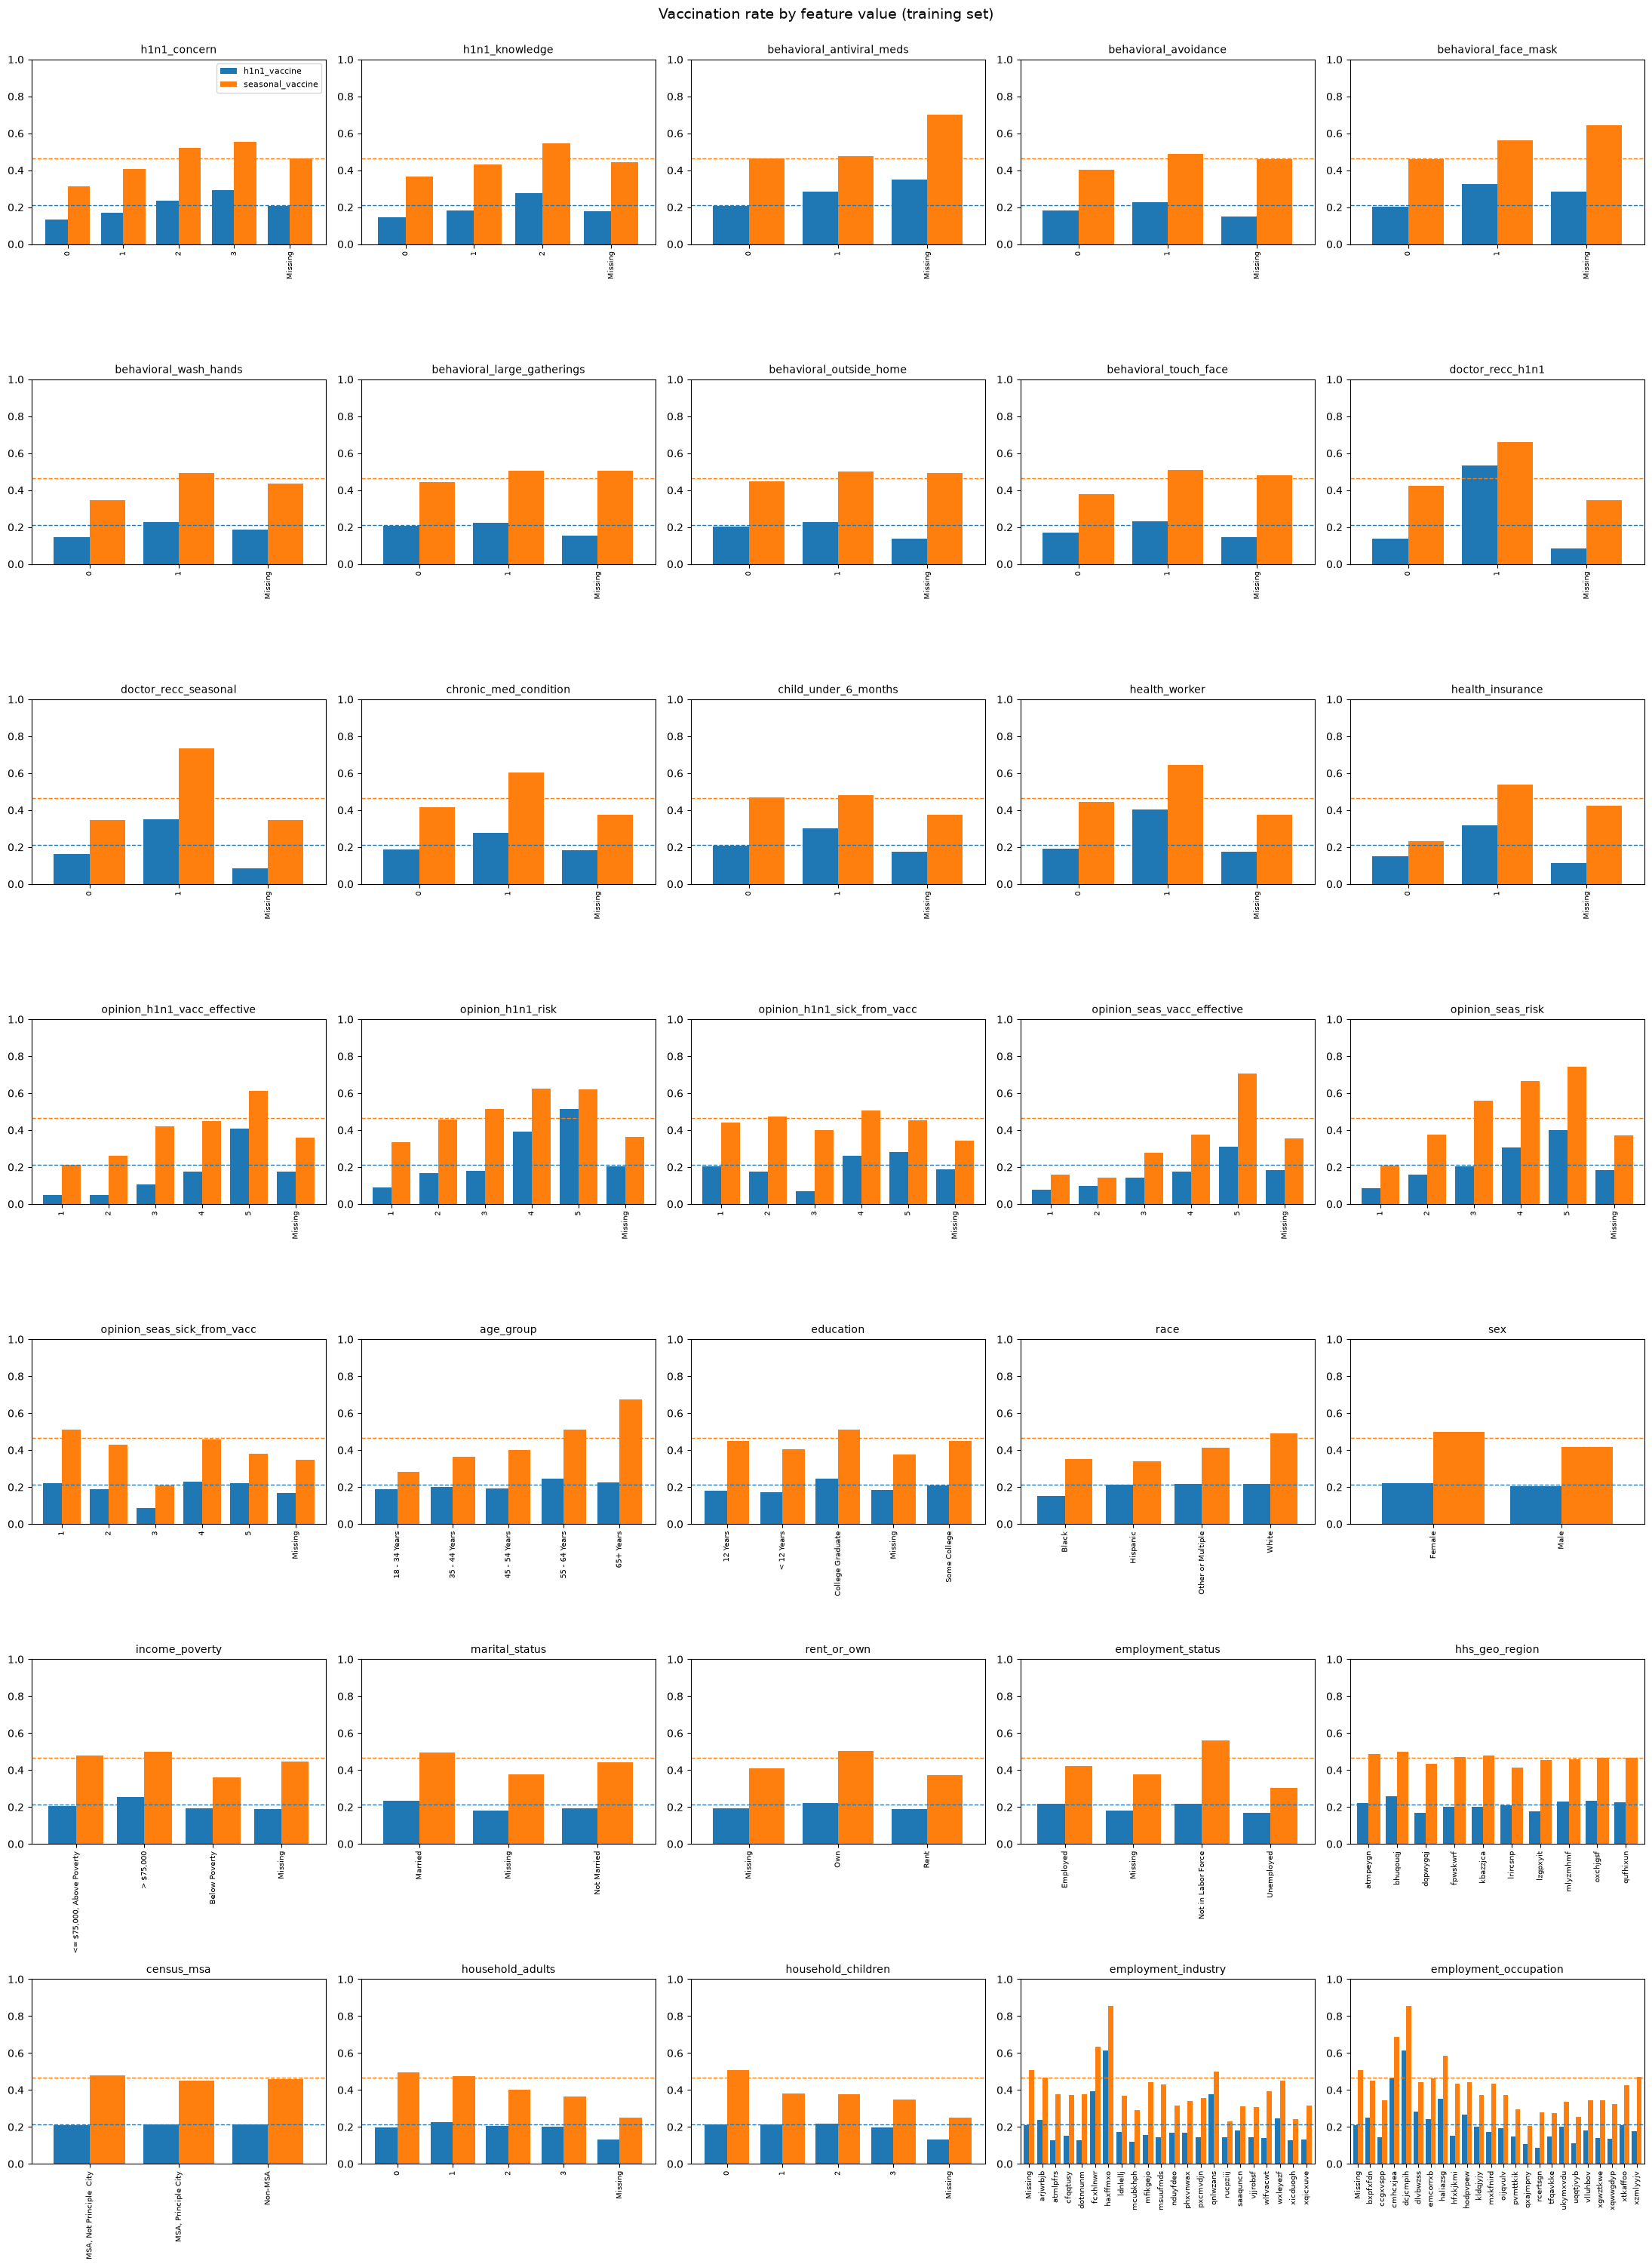

In [29]:
overall_rates = y_train.mean()

fig, axes = plt.subplots(7, 5, figsize=(22, 30))
for ax, col in zip(axes.flat, FEATURES):
    groups = as_groups(train_df[col])
    train_df.groupby(groups)[TARGETS].mean().plot(kind="bar", ax=ax, legend=False, width=0.8)
    # Dashed lines mark each target's overall rate for reference
    ax.axhline(overall_rates["h1n1_vaccine"], color="C0", linestyle="--", linewidth=1)
    ax.axhline(overall_rates["seasonal_vaccine"], color="C1", linestyle="--", linewidth=1)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", labelsize=7, rotation=90)

axes.flat[0].legend(fontsize=8)
fig.suptitle("Vaccination rate by feature value (training set)", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

### Findings from the feature-by-feature comparison

The features most strongly associated with each vaccine are specific to that vaccine. For H1N1, the largest differences in vaccination rate come from whether a doctor recommended the H1N1 vaccine (spread 0.449), the respondent's perceived H1N1 risk (0.425) and the perceived effectiveness of the H1N1 vaccine (0.357). For the seasonal vaccine, the equivalent seasonal questions lead: perceived effectiveness (0.564), perceived risk (0.536) and doctor recommendation (0.388). Vaccination rises fairly steadily with perceived risk and perceived effectiveness.

Age group is where the two targets differ most clearly. It shows one of the largest spreads for the seasonal vaccine (0.391), with the 65+ group well above the others, but almost none for H1N1 (0.054). Employment status shows a similar pattern (0.254 for seasonal against 0.053 for H1N1), with respondents not in the labour force standing out for seasonal vaccination only. This may partly overlap with age, although I have not tested that directly. Household size also matters more for the seasonal vaccine (spreads of 0.243 for adults and 0.256 for children, against under 0.1 for H1N1). Because the two targets depend on different features, I model them separately rather than assuming one set of relationships fits both.

The opinion questions use 3 for "Don't know", and this answer does not behave like a midpoint. For both "worried about getting sick from the vaccine" questions, respondents answering "Don't know" have the lowest vaccination rate of all five answers. Treating these codes as a continuous 1–5 scale would misrepresent this pattern, so I encode the opinion questions as categories.

The employment industry and occupation codes have the largest spreads, but this measure grows with the number of groups, and these columns have 21 to 23 groups. A few codes do show much higher vaccination rates than the rest, which I check further below. The behavioural features, sex, metropolitan area and region show small differences on their own, with spreads below 0.15 for both vaccines. I keep them, because a weak association on its own does not mean a feature adds nothing in combination with others.

These comparisons look at one feature at a time and show associations, not causes. Many features are likely related to each other, so their individual spreads cannot be added together.

In [30]:
for col in ["employment_occupation", "employment_industry"]:
    groups = as_groups(train_df[col])
    summary = train_df.groupby(groups).agg(
        n=("health_worker", "size"),
        health_worker_share=("health_worker", "mean"),
        h1n1_rate=("h1n1_vaccine", "mean"),
        seasonal_rate=("seasonal_vaccine", "mean"),
    )
    print(f"\n{col}: top 5 codes by H1N1 vaccination rate")
    display(summary.sort_values("h1n1_rate", ascending=False).head(5).round(3))


employment_occupation: top 5 codes by H1N1 vaccination rate


,n,health_worker_share,h1n1_rate,seasonal_rate
employment_occupation,,,,
dcjcmpih,124,0.073,0.613,0.855
cmhcxjea,1022,0.903,0.468,0.689
haliazsg,245,0.893,0.351,0.584
dlvbwzss,176,0.114,0.284,0.443
hodpvpew,177,0.220,0.266,0.441



employment_industry: top 5 codes by H1N1 vaccination rate


,n,health_worker_share,h1n1_rate,seasonal_rate
employment_industry,,,,
haxffmxo,124,0.073,0.613,0.855
fcxhlnwr,2000,0.787,0.392,0.636
qnlwzans,8,0.000,0.375,0.500
wxleyezf,1465,0.036,0.246,0.452
arjwrbjb,693,0.061,0.238,0.465


In [32]:
both_codes = (train_df["employment_occupation"] == "dcjcmpih") & (train_df["employment_industry"] == "haxffmxo")
print("Respondents with both occupation dcjcmpih and industry haxffmxo:", both_codes.sum())

Respondents with both occupation dcjcmpih and industry haxffmxo: 124


### Relationships between features

I checked how strongly the numeric survey features are correlated with each other. Highly correlated features carry overlapping information, which matters mainly when interpreting a linear model's coefficients. I used Spearman correlation because most of these variables are ordinal codes rather than continuous measurements.

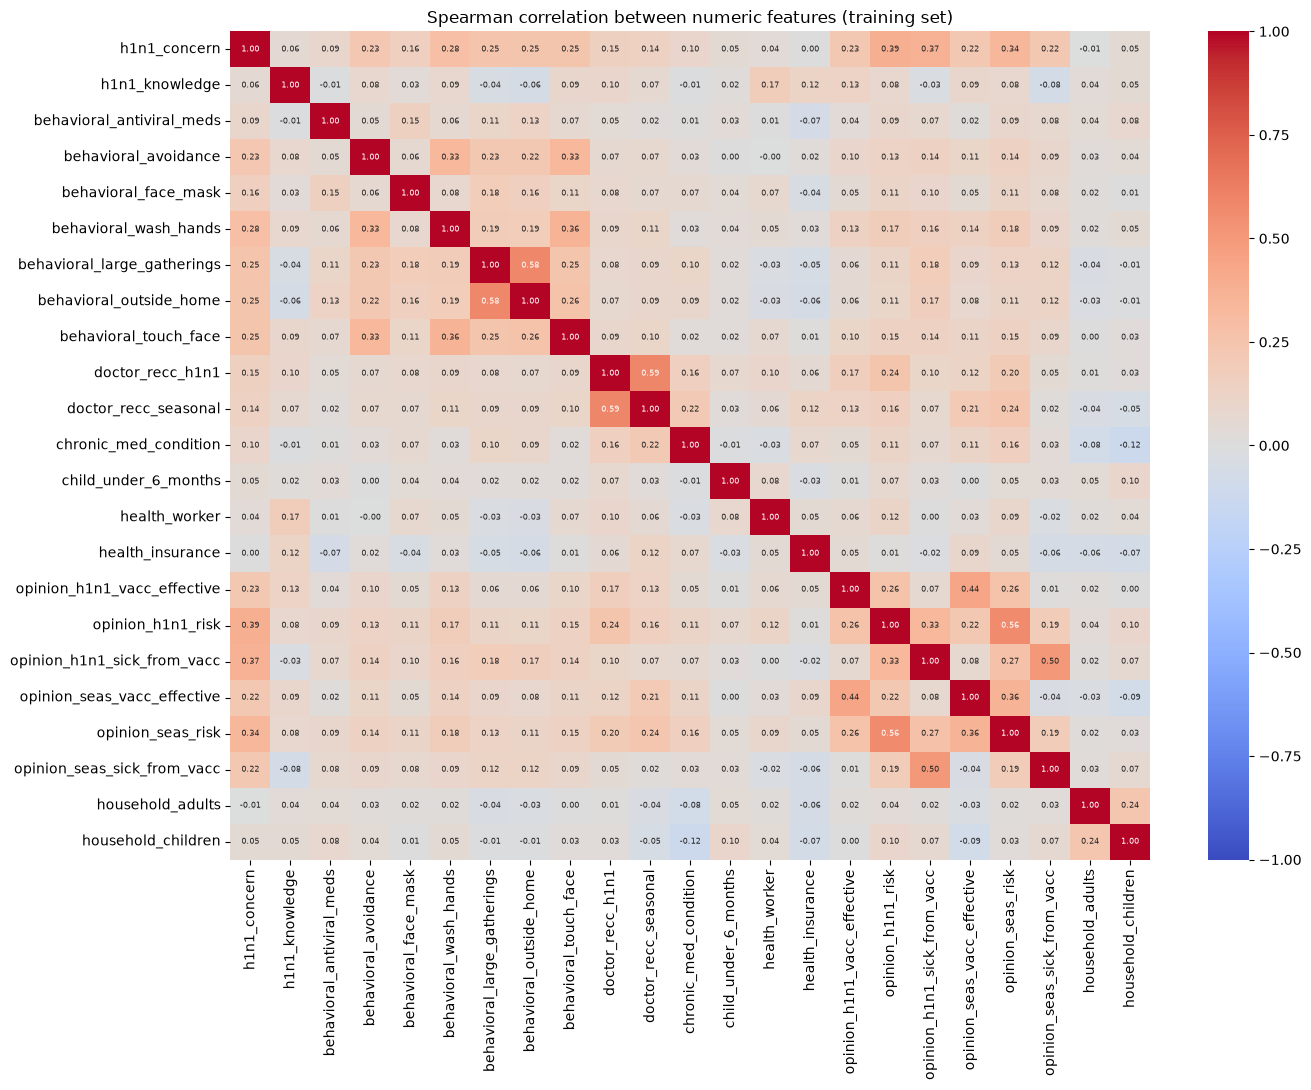

Pairs with |correlation| > 0.4:


doctor_recc_h1n1             doctor_recc_seasonal           0.594
behavioral_large_gatherings  behavioral_outside_home        0.583
opinion_h1n1_risk            opinion_seas_risk              0.563
opinion_h1n1_sick_from_vacc  opinion_seas_sick_from_vacc    0.501
opinion_h1n1_vacc_effective  opinion_seas_vacc_effective    0.439
dtype: float64

In [31]:
numeric_cols = train_df[FEATURES].select_dtypes("number").columns
corr = train_df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 6})
plt.title("Spearman correlation between numeric features (training set)")
plt.tight_layout()
plt.show()

# List the strongest pairs so they don't have to be read off the heatmap
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print("Pairs with |correlation| > 0.4:")
display(upper[upper.abs() > 0.4].sort_values(key=abs, ascending=False).round(3))

### Employment codes and feature correlations

Some of the occupation and industry codes with high vaccination rates are mostly made up of healthcare workers: 90.3% of occupation `cmhcxjea` and 78.7% of industry `fcxhlnwr` are health workers. These codes partly repeat what `health_worker` already records. The highest rates of all, however, belong to occupation `dcjcmpih` and industry `haxffmxo` (61.3% H1N1, 85.5% seasonal), which turned out to be the same 124 respondents. Only 7.3% of them are health workers, so this highly vaccinated group is not captured by `health_worker`. This is why I kept the employment codes as features despite their anonymised values. Some codes are very rare (industry `qnlwzans` has only 8 training respondents), and their rates are not reliable.

The strongest correlation between numeric features is 0.594, between the two doctor-recommendation questions. The other notable pairs are the H1N1 and seasonal versions of the same opinion question, and reducing time at large gatherings with reducing contact outside the home. None of these features are near-duplicates, so I did not remove any. The overlap does mean that a linear model's coefficients for these features cannot be read as separate, independent effects.

## Data preparation

Based on the analysis above, I prepared the features as follows:

- **Every feature is treated as categorical, with missing values as a separate "Missing" category.** All 35 features are discrete, with at most 23 distinct values. The opinion questions include a "Don't know" code that does not behave like a midpoint, and missingness is associated with vaccination for several features. Treating every value, including "Missing", as its own category handles all three issues with one consistent rule. The cost is that ordered features such as concern, knowledge and age lose their ordering, but with 3 to 5 levels each a model can still learn a separate effect for each level.
- **The conversion to categories is a fixed rule applied row by row.** It does not learn anything from the data, so applying it to both the training and test sets cannot leak information from the test set.
- **Categories are one-hot encoded, and rare categories are grouped together.** Categories with fewer than 25 training respondents are merged into a single "infrequent" group, so tiny groups with unreliable rates do not get their own column. Any category that appears only in the test set is assigned to this group. The encoder is fitted inside each model's pipeline, so during cross-validation it only learns categories from the training part of each fold.
- **No scaling is applied**, because after one-hot encoding every column is 0 or 1.

In [34]:
from sklearn.preprocessing import OneHotEncoder

# Fixed row-by-row conversion: floats shown as whole numbers, blanks become "Missing"
X_train_cat = X_train.apply(as_groups)
X_test_cat = X_test.apply(as_groups)

# Every original missing value must now be exactly one "Missing" entry, with no NaN left
assert X_train_cat.isna().sum().sum() == 0 and X_test_cat.isna().sum().sum() == 0
assert ((X_train_cat == "Missing").sum() == X_train.isna().sum()).all()
assert ((X_test_cat == "Missing").sum() == X_test.isna().sum()).all()
print("Missing values correctly converted to 'Missing' in both sets")

# Fitted on the training set here only to inspect the result;
# for modeling it is refitted inside each pipeline
encoder = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=25, sparse_output=False)
encoder.fit(X_train_cat)

print("\nEncoded columns:", len(encoder.get_feature_names_out()))

print("\nCategories merged into 'infrequent':")
for col, cats in zip(X_train_cat.columns, encoder.infrequent_categories_):
    if cats is not None:
        print(f"  {col}: {list(cats)}")

print("\nCategories in the test set that never appear in training:")
for col in X_test_cat.columns:
    unseen = set(X_test_cat[col]) - set(X_train_cat[col])
    if unseen:
        print(f"  {col}: {unseen}")

Missing values correctly converted to 'Missing' in both sets

Encoded columns: 183

Categories merged into 'infrequent':
  behavioral_face_mask: ['Missing']
  employment_industry: ['qnlwzans']

Categories in the test set that never appear in training:


## Modeling setup

I trained a separate model for each target, since the EDA showed that the two vaccines are associated with different features.

Models are compared using 5-fold cross-validation on the training set only; the test set is kept aside until a final model has been chosen. Every model and both targets use exactly the same five folds, stratified on the combination of the two targets in the same way as the test split, so differences between models are not caused by different data. The one-hot encoder sits inside each model's pipeline, so in every fold it is fitted only on that fold's training part.

I recorded four metrics for each model:
- **ROC-AUC** (main metric): how well the model ranks vaccinated respondents above unvaccinated ones, regardless of any threshold.
- **Average precision**: summarises precision across all thresholds and focuses on the vaccinated class, which is more informative for the imbalanced H1N1 target.
- **Log loss** and **Brier score**: measure the quality of the predicted probabilities themselves. Lower is better. These matter because the task asks for probabilities, not only yes/no predictions.

I also recorded the standard deviation of each metric across the five folds, to judge whether differences between models are larger than normal fold-to-fold variation.

As a baseline, I used a model that predicts the training vaccination rate for every respondent. It shows what each metric looks like when nothing is learned from the features. The first real model is logistic regression with the default L2 regularisation, chosen because it is interpretable and the regularisation handles the moderately correlated question pairs found earlier.

In [42]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# The same 5 folds are reused for every model and both targets,
# stratified on the combination of the two targets
train_strata = y_train["h1n1_vaccine"].astype(str) + "_" + y_train["seasonal_vaccine"].astype(str)
cv_folds = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
                .split(X_train_cat, train_strata))

SCORING = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "log_loss": "neg_log_loss",
    "brier": "neg_brier_score",
}

cv_results = []  # one row per model and target, used later for the comparison table

def evaluate(name, model):
    # Drop earlier rows for this model so re-running a cell doesn't duplicate results
    cv_results[:] = [r for r in cv_results if r["model"] != name]
    for target in TARGETS:
        pipe = make_pipeline(
            OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=25, sparse_output=False),
            # A dict gives each target its own tuned model; otherwise the same model is used for both
            model[target] if isinstance(model, dict) else model,
        )
        scores = cross_validate(pipe, X_train_cat, y_train[target], cv=cv_folds,
                                scoring=SCORING, n_jobs=-1)
        row = {"model": name, "target": target}
        for metric in SCORING:
            values = scores[f"test_{metric}"]
            if metric in ("log_loss", "brier"):
                values = -values  # sklearn reports these as negatives; flip so lower = better
            row[f"{metric}_mean"] = values.mean()
            row[f"{metric}_std"] = values.std()
        row["fit_time_s"] = scores["fit_time"].mean()
        cv_results.append(row)
    return pd.DataFrame([r for r in cv_results if r["model"] == name]).round(4)

In [43]:
display(evaluate("Baseline (class prior)", DummyClassifier(strategy="prior")))

,model,target,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,log_loss_mean,log_loss_std,brier_mean,brier_std,fit_time_s
0,Baseline (class prior),h1n1_vaccine,0.5,0.0,0.2125,0.0001,0.5172,0.0001,0.1673,0.0001,0.9266
1,Baseline (class prior),seasonal_vaccine,0.5,0.0,0.4656,0.0001,0.6908,0.0000,0.2488,0.0000,0.9506


In [44]:
display(evaluate("Logistic regression", LogisticRegression(max_iter=1000)))

,model,target,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,log_loss_mean,log_loss_std,brier_mean,brier_std,fit_time_s
0,Logistic regression,h1n1_vaccine,0.8613,0.0068,0.6805,0.0137,0.3522,0.0072,0.1080,0.0026,1.2820
1,Logistic regression,seasonal_vaccine,0.8579,0.0040,0.8376,0.0051,0.4700,0.0064,0.1521,0.0022,1.4403


### Baseline and logistic regression

The baseline behaves as expected. It has a ROC-AUC of 0.5, meaning no ability to rank respondents, and its average precision equals the vaccination rate in the training data (0.2125 for H1N1, 0.4656 for seasonal). Its log loss (0.5172 and 0.6908) and Brier score (0.1673 and 0.2488) show what these metrics look like when nothing is learned from the features.

Logistic regression is far better on every metric. Its ROC-AUC is 0.8613 for H1N1 and 0.8579 for seasonal. For H1N1, average precision rises from 0.2125 to 0.6805, and log loss falls from 0.5172 to 0.3522. The standard deviation of ROC-AUC across the five folds is small (0.0068 and 0.0040), so results are stable between folds. It also means differences between models of about 0.01 ROC-AUC are worth taking seriously, while differences of 0.002–0.003 are within normal fold-to-fold variation.

### Additional models

I compared three further approaches:
- **Logistic regression with class weighting**, to test whether the H1N1 imbalance (21.2% vaccinated) needs treatment. Class weighting gives the minority class more influence during training. It usually does not change how well a model ranks respondents, and it pushes predicted probabilities upwards, so it may worsen probability quality. I tested this rather than assuming it.
- **Random forest**, a nonlinear model that can capture interactions between features, which logistic regression cannot do without manually added terms. I set a minimum of 5 respondents per leaf, because fully grown trees tend to produce overconfident probabilities.
- **Histogram gradient boosting**, another nonlinear tree-based method that builds trees sequentially, each one correcting the errors of the previous ones.

All models use the same preprocessing and the same five folds, so their results can be compared directly.

In [45]:
display(evaluate("Logistic regression (balanced weights)",
                 LogisticRegression(max_iter=1000, class_weight="balanced")))

,model,target,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,log_loss_mean,log_loss_std,brier_mean,brier_std,fit_time_s
0,Logistic regression (balanced weights),h1n1_vaccine,0.8611,0.0069,0.6762,0.0132,0.4568,0.0092,0.1468,0.0035,1.4881
1,Logistic regression (balanced weights),seasonal_vaccine,0.8579,0.0040,0.8375,0.0051,0.4714,0.0064,0.1526,0.0022,1.4258


In [46]:
from sklearn.ensemble import RandomForestClassifier

display(evaluate("Random forest",
                 RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                        random_state=RANDOM_STATE)))

,model,target,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,log_loss_mean,log_loss_std,brier_mean,brier_std,fit_time_s
0,Random forest,h1n1_vaccine,0.8627,0.0057,0.6834,0.0163,0.3582,0.0051,0.1097,0.0020,9.3393
1,Random forest,seasonal_vaccine,0.8566,0.0054,0.8359,0.0079,0.4830,0.0059,0.1566,0.0025,9.5869


### Class weighting and random forest

Class weighting did not improve the logistic regression model. For H1N1, ROC-AUC stayed essentially the same (0.8611 against 0.8613 without weighting), and average precision was slightly lower (0.6762 against 0.6805). The quality of the predicted probabilities became clearly worse: log loss increased from 0.3522 to 0.4568 and the Brier score from 0.1080 to 0.1468. Weighting pushed predictions upwards, so they no longer matched the actual vaccination rate. For the seasonal vaccine, which is close to balanced, weighting made almost no difference. Because the task asks for probabilities, I did not use class weighting. If a yes/no decision were needed, adjusting the decision threshold on well-calibrated probabilities would be a better option than distorting the probabilities during training.

The random forest performed about the same as logistic regression. Its H1N1 ROC-AUC (0.8627) was only 0.0014 higher, well within the fold-to-fold variation, and its seasonal ROC-AUC was slightly lower (0.8566 against 0.8579). Its probabilities were slightly worse for both targets (log loss 0.3582 against 0.3522 for H1N1, and 0.4830 against 0.4700 for seasonal), and it took about seven times longer to train. Capturing interactions between features did not bring a meaningful improvement here.

In [47]:
from sklearn.ensemble import HistGradientBoostingClassifier

display(evaluate("Gradient boosting",
                 HistGradientBoostingClassifier(random_state=RANDOM_STATE)))

,model,target,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,log_loss_mean,log_loss_std,brier_mean,brier_std,fit_time_s
0,Gradient boosting,h1n1_vaccine,0.8642,0.0051,0.6867,0.0165,0.3482,0.0065,0.1066,0.0025,4.5867
1,Gradient boosting,seasonal_vaccine,0.8602,0.0045,0.8406,0.0054,0.4657,0.0065,0.1509,0.0024,5.1185


### Gradient boosting and the decision to tune

Gradient boosting achieved the best result on every metric for both targets: ROC-AUC of 0.8642 for H1N1 and 0.8602 for seasonal, and the lowest log loss (0.3482 and 0.4657) and Brier score (0.1066 and 0.1509). Its advantage over logistic regression is small, 0.0029 and 0.0023 in ROC-AUC, which is less than one fold standard deviation. It is, however, consistent across all four metrics and both targets.

So far every model used default or near-default settings. I tuned the two strongest candidates:
- **Logistic regression**: the regularisation strength `C`.
- **Gradient boosting**: the learning rate, the maximum number of leaves per tree and the minimum number of respondents per leaf, with early stopping choosing the number of trees.

I did not tune the random forest, since it was no better than logistic regression, had worse probabilities and was the slowest model to train.

Tuning was done separately for each target, using ROC-AUC on the same five folds. Because the same folds are used for tuning and for reporting, the tuned cross-validation scores are slightly optimistic. This is one reason the final model is evaluated on the untouched test set.

In [48]:
from sklearn.model_selection import GridSearchCV

def tune(model, param_grid):
    tuned = {}
    for target in TARGETS:
        pipe = make_pipeline(
            OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=25, sparse_output=False),
            model,
        )
        search = GridSearchCV(pipe, param_grid, cv=cv_folds, scoring="roc_auc", n_jobs=-1)
        search.fit(X_train_cat, y_train[target])
        scores = search.cv_results_["mean_test_score"]
        print(f"{target}: best ROC-AUC {search.best_score_:.4f} "
              f"(range across settings {scores.min():.4f}–{scores.max():.4f})")
        print(f"  best settings: {search.best_params_}")
        tuned[target] = search.best_estimator_[-1]  # the model step with the chosen settings
    return tuned

In [49]:
lr_tuned = tune(
    LogisticRegression(max_iter=1000),
    {"logisticregression__C": [0.01, 0.03, 0.1, 0.3, 1, 3]},
)

h1n1_vaccine: best ROC-AUC 0.8618 (range across settings 0.8593–0.8618)
  best settings: {'logisticregression__C': 0.1}
seasonal_vaccine: best ROC-AUC 0.8585 (range across settings 0.8565–0.8585)
  best settings: {'logisticregression__C': 0.1}


In [52]:
gb_tuned = tune(
    HistGradientBoostingClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_STATE),
    {
        "histgradientboostingclassifier__learning_rate": [0.03, 0.05, 0.1],
        "histgradientboostingclassifier__max_leaf_nodes": [7, 15, 31],
        "histgradientboostingclassifier__min_samples_leaf": [20, 50, 100],
    },
)

h1n1_vaccine: best ROC-AUC 0.8669 (range across settings 0.8624–0.8669)
  best settings: {'histgradientboostingclassifier__learning_rate': 0.03, 'histgradientboostingclassifier__max_leaf_nodes': 15, 'histgradientboostingclassifier__min_samples_leaf': 50}
seasonal_vaccine: best ROC-AUC 0.8617 (range across settings 0.8579–0.8617)
  best settings: {'histgradientboostingclassifier__learning_rate': 0.05, 'histgradientboostingclassifier__max_leaf_nodes': 15, 'histgradientboostingclassifier__min_samples_leaf': 50}


In [53]:
display(evaluate("Logistic regression (tuned)", lr_tuned))
display(evaluate("Gradient boosting (tuned)", gb_tuned))

,model,target,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,log_loss_mean,log_loss_std,brier_mean,brier_std,fit_time_s
0,Logistic regression (tuned),h1n1_vaccine,0.8618,0.0065,0.6811,0.0140,0.3516,0.0067,0.1079,0.0025,1.2432
1,Logistic regression (tuned),seasonal_vaccine,0.8585,0.0040,0.8385,0.0054,0.4690,0.0063,0.1518,0.0022,1.3190


,model,target,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,log_loss_mean,log_loss_std,brier_mean,brier_std,fit_time_s
0,Gradient boosting (tuned),h1n1_vaccine,0.8669,0.0052,0.6936,0.0143,0.3456,0.0063,0.1058,0.0025,9.4098
1,Gradient boosting (tuned),seasonal_vaccine,0.8617,0.0037,0.8421,0.0052,0.4637,0.0052,0.1501,0.0020,6.4248


In [54]:
# Paired comparison: both tuned models scored on the same five folds
fold_auc = {}
for target in TARGETS:
    for label, tuned in [("LR", lr_tuned), ("GB", gb_tuned)]:
        pipe = make_pipeline(
            OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=25, sparse_output=False),
            tuned[target],
        )
        fold_auc[(target, label)] = cross_validate(
            pipe, X_train_cat, y_train[target], cv=cv_folds, scoring="roc_auc", n_jobs=-1
        )["test_score"]

for target in TARGETS:
    diff = fold_auc[(target, "GB")] - fold_auc[(target, "LR")]
    print(f"{target}: gradient boosting minus logistic regression, ROC-AUC per fold: {np.round(diff, 4)}")
    print(f"  gradient boosting better in {(diff > 0).sum()} of {len(diff)} folds, mean difference {diff.mean():.4f}")

h1n1_vaccine: gradient boosting minus logistic regression, ROC-AUC per fold: [0.0114 0.004  0.0032 0.0026 0.0044]
  gradient boosting better in 5 of 5 folds, mean difference 0.0051
seasonal_vaccine: gradient boosting minus logistic regression, ROC-AUC per fold: [0.0025 0.0057 0.0034 0.0028 0.0017]
  gradient boosting better in 5 of 5 folds, mean difference 0.0032


### Tuning results and paired comparison

Tuning barely changed logistic regression. The best regularisation strength was `C = 0.1` for both targets, and every value tried scored within about 0.0025 ROC-AUC of the best (0.8593–0.8618 for H1N1). The tuned model reached 0.8618 for H1N1 and 0.8585 for seasonal, compared with 0.8613 and 0.8579 using the default settings.

For gradient boosting, my first grid selected the most conservative value of every setting, all at the edge of the grid. When the best value is on the boundary, a better value may lie beyond it, so I widened the grid in every direction. With the wider grid, 15 leaves per tree and at least 50 respondents per leaf were selected for both targets, now in the middle of the tested ranges. For H1N1, the smallest learning rate (0.03) was again selected, but it improved ROC-AUC by only 0.0004 over the previous best, so I did not extend the search further. The tuned model reached a ROC-AUC of 0.8669 for H1N1 and 0.8617 for seasonal. For H1N1 it also had the lowest log loss (0.3456) and Brier score (0.1058) of all models.

Because every model was scored on the same five folds, I compared tuned gradient boosting and tuned logistic regression fold by fold. Gradient boosting had the higher ROC-AUC in all five folds for both targets, with an average advantage of 0.0051 for H1N1 and 0.0032 for seasonal. The advantage is small but consistent, rather than the result of one favourable fold.

One caution applies here. Gradient boosting was tuned over 27 settings and logistic regression over 6, using the same folds that produced these scores. Trying more settings increases the chance of selecting one that fits these folds by luck, so gradient boosting's advantage in cross-validation may be slightly overstated. The held-out test set provides an unbiased check.


h1n1_vaccine (5-fold cross-validation on the training set)


,roc_auc_mean,roc_auc_std,avg_precision_mean,log_loss_mean,brier_mean,fit_time_s
model,,,,,,
Gradient boosting (tuned),0.8669,0.0052,0.6936,0.3456,0.1058,9.4098
Gradient boosting,0.8642,0.0051,0.6867,0.3482,0.1066,4.5867
Random forest,0.8627,0.0057,0.6834,0.3582,0.1097,9.3393
Logistic regression (tuned),0.8618,0.0065,0.6811,0.3516,0.1079,1.2432
Logistic regression,0.8613,0.0068,0.6805,0.3522,0.1080,1.2820
Logistic regression (balanced weights),0.8611,0.0069,0.6762,0.4568,0.1468,1.4881
Baseline (class prior),0.5000,0.0000,0.2125,0.5172,0.1673,0.9266



seasonal_vaccine (5-fold cross-validation on the training set)


,roc_auc_mean,roc_auc_std,avg_precision_mean,log_loss_mean,brier_mean,fit_time_s
model,,,,,,
Gradient boosting (tuned),0.8617,0.0037,0.8421,0.4637,0.1501,6.4248
Gradient boosting,0.8602,0.0045,0.8406,0.4657,0.1509,5.1185
Logistic regression (tuned),0.8585,0.0040,0.8385,0.4690,0.1518,1.3190
Logistic regression (balanced weights),0.8579,0.0040,0.8375,0.4714,0.1526,1.4258
Logistic regression,0.8579,0.0040,0.8376,0.4700,0.1521,1.4403
Random forest,0.8566,0.0054,0.8359,0.4830,0.1566,9.5869
Baseline (class prior),0.5000,0.0000,0.4656,0.6908,0.2488,0.9506


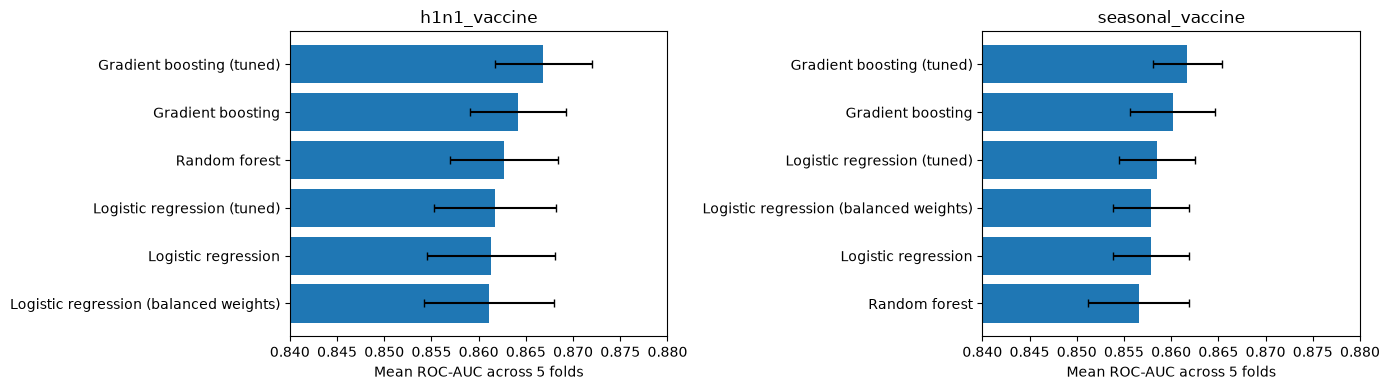

In [55]:
comparison = pd.DataFrame(cv_results)
table_cols = ["roc_auc_mean", "roc_auc_std", "avg_precision_mean",
              "log_loss_mean", "brier_mean", "fit_time_s"]

for target in TARGETS:
    print(f"\n{target} (5-fold cross-validation on the training set)")
    display(comparison[comparison["target"] == target]
            .set_index("model")[table_cols]
            .sort_values("roc_auc_mean", ascending=False)
            .round(4))

# ROC-AUC with fold standard deviation; the baseline (0.5) is left out so the differences are visible
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for ax, target in zip(axes, TARGETS):
    subset = comparison[(comparison["target"] == target) &
                        (comparison["model"] != "Baseline (class prior)")].sort_values("roc_auc_mean")
    ax.barh(subset["model"], subset["roc_auc_mean"], xerr=subset["roc_auc_std"], capsize=3)
    ax.set_title(target)
    ax.set_xlabel("Mean ROC-AUC across 5 folds")
    ax.set_xlim(0.84, 0.88)
plt.tight_layout()
plt.show()

## Model comparison and selection

The tables and chart above bring together all cross-validation results. For both targets, tuned gradient boosting has the highest ROC-AUC (0.8669 for H1N1, 0.8617 for seasonal), the highest average precision (0.6936 and 0.8421) and the lowest log loss (0.3456 and 0.4637) and Brier score (0.1058 and 0.1501). Tuned logistic regression is the closest alternative among the simpler models. The random forest ranks third for H1N1 but last among the trained models for seasonal.

The error bars in the chart overlap for all trained models, because the differences between them are of a similar size to the fold-to-fold variation. The paired comparison is therefore more informative than the averages alone: tuned gradient boosting beat tuned logistic regression in every one of the five folds for both targets.

Based on these cross-validation results, and before using the test set, I selected tuned gradient boosting as the final model for both targets. Tuned logistic regression is also scored on the test set below, but only as a reference point. It does not affect the choice of model.

## Final model evaluation on the test set

In [56]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, brier_score_loss

final_models = {}   # tuned gradient boosting pipeline for each target, fitted on the full training set
test_probs = {}     # predicted probabilities on the test set, used for later analysis
test_rows = []

for target in TARGETS:
    for name, tuned in [("Gradient boosting (tuned)", gb_tuned), ("Logistic regression (tuned)", lr_tuned)]:
        pipe = make_pipeline(
            OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=25, sparse_output=False),
            clone(tuned[target]),
        )
        pipe.fit(X_train_cat, y_train[target])
        probs = pipe.predict_proba(X_test_cat)[:, 1]
        test_probs[(target, name)] = probs
        if name == "Gradient boosting (tuned)":
            final_models[target] = pipe

        test_rows.append({
            "model": name,
            "target": target,
            "roc_auc": roc_auc_score(y_test[target], probs),
            "avg_precision": average_precision_score(y_test[target], probs),
            "log_loss": log_loss(y_test[target], probs),
            "brier": brier_score_loss(y_test[target], probs),
        })

test_results = pd.DataFrame(test_rows)
display(test_results.round(4))

,model,target,roc_auc,avg_precision,log_loss,brier
0,Gradient boosting (tuned),h1n1_vaccine,0.8761,0.7001,0.3382,0.1041
1,Logistic regression (tuned),h1n1_vaccine,0.8693,0.6839,0.3456,0.1071
2,Gradient boosting (tuned),seasonal_vaccine,0.8621,0.8422,0.4630,0.1505
3,Logistic regression (tuned),seasonal_vaccine,0.8595,0.8371,0.4670,0.1517


On the test set, tuned gradient boosting again performed best on every metric for both targets. For H1N1 it reached a ROC-AUC of 0.8761, against 0.8693 for logistic regression. For seasonal the figures were 0.8621 and 0.8595. Its log loss and Brier score were also lower for both targets. The gaps between the two models (0.0068 and 0.0026 in ROC-AUC) are in line with what cross-validation showed, so the larger tuning grid used for gradient boosting did not create an advantage that disappeared on new data.

The H1N1 test scores are higher than the cross-validation scores (0.8761 against 0.8669). This is unlikely to indicate a problem, because logistic regression rose by a similar amount (0.8618 to 0.8693). The test set is a single sample of 5,342 respondents, so some variation is expected, and this sample appears slightly easier to predict for H1N1. For seasonal, the test and cross-validation scores are almost identical.

h1n1_vaccine: mean predicted 0.214, actual rate 0.212, largest bin gap 0.030
seasonal_vaccine: mean predicted 0.466, actual rate 0.466, largest bin gap 0.045


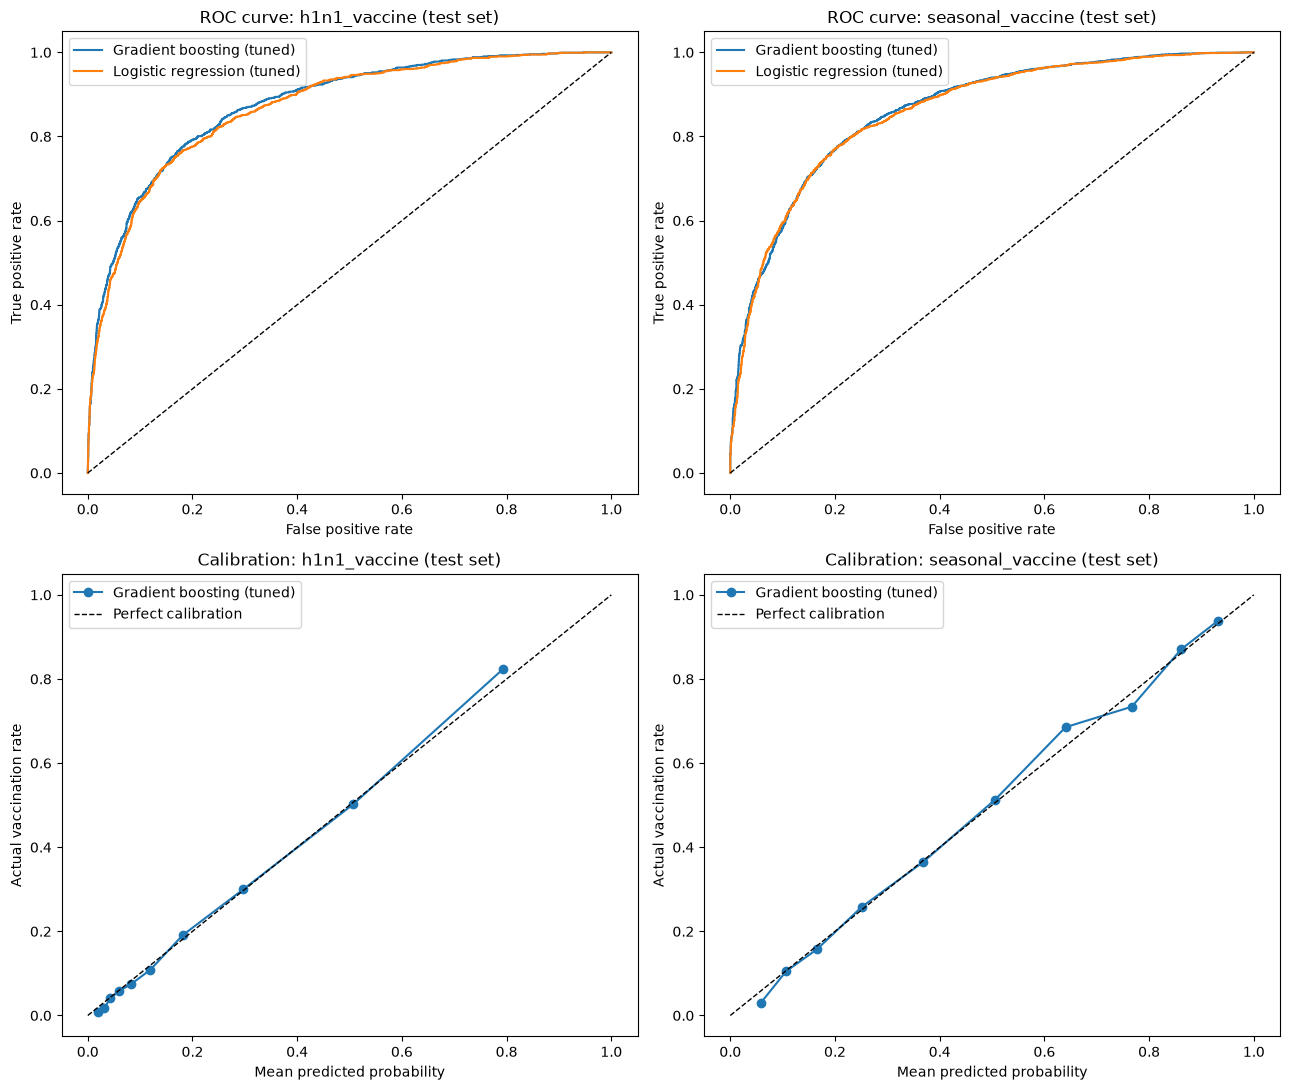

In [57]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve

GB = "Gradient boosting (tuned)"
LR = "Logistic regression (tuned)"

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for col, target in enumerate(TARGETS):
    # ROC curves: both models on the test set
    ax = axes[0, col]
    for name in [GB, LR]:
        fpr, tpr, _ = roc_curve(y_test[target], test_probs[(target, name)])
        ax.plot(fpr, tpr, label=name)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(f"ROC curve: {target} (test set)")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend()

    # Calibration: predicted probability vs actual vaccination rate, 10 equal-sized bins
    ax = axes[1, col]
    probs = test_probs[(target, GB)]
    frac_pos, mean_pred = calibration_curve(y_test[target], probs, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", label=GB)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.set_title(f"Calibration: {target} (test set)")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Actual vaccination rate")
    ax.legend()

    print(f"{target}: mean predicted {probs.mean():.3f}, actual rate {y_test[target].mean():.3f}, "
          f"largest bin gap {np.abs(frac_pos - mean_pred).max():.3f}")

plt.tight_layout()
plt.show()

The ROC curves of the two models almost overlap. Gradient boosting sits slightly above logistic regression for H1N1 at low false positive rates, which matches the small difference in ROC-AUC. Both models capture the same broad signal, and gradient boosting refines it slightly.

Since the task asks for probabilities, calibration matters as much as ranking. The final model's probabilities are well calibrated on the test set. The average predicted probability matches the actual vaccination rate almost exactly (0.214 against 0.212 for H1N1, and 0.466 against 0.466 for seasonal). In the calibration plots, the points lie close to the diagonal, and the largest gap in any bin is 0.030 for H1N1 and 0.045 for seasonal. A predicted probability of, for example, 30% therefore corresponds closely to about 30% of such respondents actually being vaccinated. Because of this, I did not apply any additional calibration.

In [58]:
from sklearn.metrics import confusion_matrix, classification_report

for target in TARGETS:
    preds = (test_probs[(target, GB)] >= 0.5).astype(int)
    print(f"\n{target}, threshold 0.5 (rows = actual, columns = predicted)")
    print(confusion_matrix(y_test[target], preds))
    print(classification_report(y_test[target], preds, digits=3))


h1n1_vaccine, threshold 0.5 (rows = actual, columns = predicted)
[[3989  218]
 [ 553  582]]
              precision    recall  f1-score   support

           0      0.878     0.948     0.912      4207
           1      0.728     0.513     0.602      1135

    accuracy                          0.856      5342
   macro avg      0.803     0.730     0.757      5342
weighted avg      0.846     0.856     0.846      5342


seasonal_vaccine, threshold 0.5 (rows = actual, columns = predicted)
[[2312  542]
 [ 603 1885]]
              precision    recall  f1-score   support

           0      0.793     0.810     0.802      2854
           1      0.777     0.758     0.767      2488

    accuracy                          0.786      5342
   macro avg      0.785     0.784     0.784      5342
weighted avg      0.785     0.786     0.785      5342



The main output of the model is a probability, but I also checked what happens if a yes/no decision is made at a threshold of 0.5. For H1N1, accuracy is 0.856, which looks high but should be compared with 0.788, the accuracy of predicting "not vaccinated" for everyone. At this threshold the model identifies only 51.3% of vaccinated respondents (582 of 1,135), although 72.8% of its "vaccinated" predictions are correct. Because only about 21% of respondents received the H1N1 vaccine, 0.5 is a high threshold for this target. For the seasonal vaccine, where the classes are close to balanced, the results are more even: 75.8% of vaccinated and 81.0% of unvaccinated respondents are classified correctly, with an accuracy of 0.786.

This shows that the threshold should be chosen based on how the predictions will be used. For example, a vaccination outreach programme might accept more false positives in exchange for finding more of the relevant people. Since the probabilities are well calibrated, a threshold can be chosen later for a specific purpose without retraining the model.

target,h1n1_vaccine,seasonal_vaccine
feature,,
doctor_recc_h1n1,0.0832,0.0013
health_insurance,0.0635,0.0060
opinion_h1n1_risk,0.0360,0.0009
opinion_h1n1_vacc_effective,0.0293,0.0006
health_worker,0.0095,0.0044
doctor_recc_seasonal,0.0059,0.0477
opinion_seas_risk,0.0036,0.0703
employment_industry,0.0035,0.0036
age_group,0.0025,0.0308


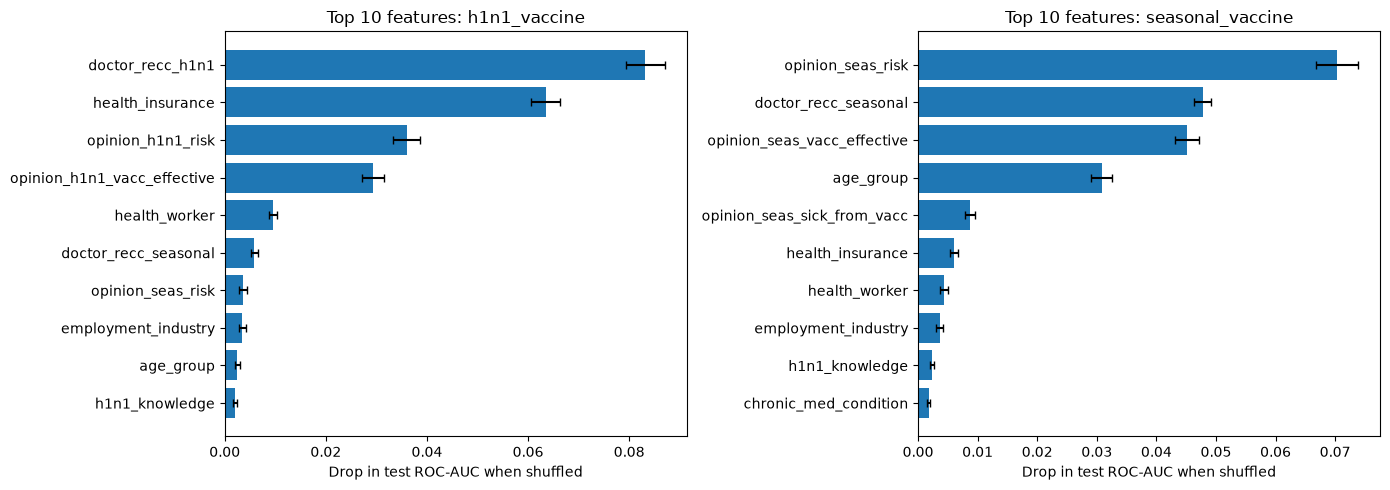

In [59]:
from sklearn.inspection import permutation_importance

importance_frames = []
for target in TARGETS:
    result = permutation_importance(
        final_models[target], X_test_cat, y_test[target],
        scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
    )
    importance_frames.append(pd.DataFrame({
        "feature": X_test_cat.columns,
        "target": target,
        "auc_drop": result.importances_mean,
        "std": result.importances_std,
    }))
importance = pd.concat(importance_frames)

importance_table = (importance.pivot(index="feature", columns="target", values="auc_drop")
                    .sort_values("h1n1_vaccine", ascending=False))
display(importance_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, TARGETS):
    top = importance[importance["target"] == target].nlargest(10, "auc_drop").sort_values("auc_drop")
    ax.barh(top["feature"], top["auc_drop"], xerr=top["std"], capsize=3)
    ax.set_title(f"Top 10 features: {target}")
    ax.set_xlabel("Drop in test ROC-AUC when shuffled")
plt.tight_layout()
plt.show()

Permutation importance measures how much the test ROC-AUC drops when one feature's values are randomly shuffled, which breaks its relationship with the target.

For H1N1, the model relies mostly on whether a doctor recommended the H1N1 vaccine (a drop of 0.0832) and on health insurance (0.0635), followed by the respondent's views on H1N1 risk (0.0360) and vaccine effectiveness (0.0293), and whether they are a health worker (0.0095). For the seasonal vaccine, the most important features are perceived seasonal risk (0.0703), a doctor's recommendation for the seasonal vaccine (0.0477), perceived seasonal vaccine effectiveness (0.0452) and age group (0.0308). Age group is important for the seasonal vaccine but hardly used for H1N1 (0.0025). This matches the EDA finding that the two vaccines are associated with different features and supports modelling them separately.

Health insurance is more important to the H1N1 model than its spread in the EDA suggested. Its "Missing" category covers 46% of respondents and had a much lower H1N1 vaccination rate, so part of this importance reflects whether the question was answered rather than the answer itself. The employment codes contribute little (0.0035 or less) despite their large spreads in the EDA, which suggests their information largely overlaps with features such as `health_worker`. The behavioural features have almost no effect, and the small negative values for some features are random variation around zero.

These importances describe what the model uses to make predictions, not causes of vaccination. Permutation importance also understates features that have a correlated partner, such as the two doctor-recommendation questions, because when one is shuffled the model can still use the other.

In [60]:
# Same tuned gradient boosting settings and same folds, but without race, sex and income
sensitive = ["race", "sex", "income_poverty"]
X_train_reduced = X_train_cat.drop(columns=sensitive)

for target in TARGETS:
    pipe = make_pipeline(
        OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=25, sparse_output=False),
        clone(gb_tuned[target]),
    )
    reduced = cross_validate(pipe, X_train_reduced, y_train[target], cv=cv_folds,
                             scoring="roc_auc", n_jobs=-1)["test_score"]
    full = fold_auc[(target, "GB")]
    print(f"{target}: ROC-AUC with all features {full.mean():.4f}, "
          f"without {sensitive} {reduced.mean():.4f}")
    print(f"  difference per fold (without minus with): {np.round(reduced - full, 4)}")

h1n1_vaccine: ROC-AUC with all features 0.8669, without ['race', 'sex', 'income_poverty'] 0.8659
  difference per fold (without minus with): [-0.0025 -0.0001 -0.0011 -0.001   0.0001]
seasonal_vaccine: ROC-AUC with all features 0.8617, without ['race', 'sex', 'income_poverty'] 0.8610
  difference per fold (without minus with): [-0.0011 -0.0001 -0.001  -0.0006 -0.0008]


Race, sex and income contributed very little in the importance analysis (at most 0.0016), so I checked how the final model performs without them, using the same tuned settings and folds. Mean ROC-AUC fell by only 0.0010 for H1N1 (0.8669 to 0.8659) and 0.0007 for seasonal (0.8617 to 0.8610). The reduced model was slightly worse in four of five folds for H1N1 and in all five for seasonal, so these attributes carry a small amount of real information, but the loss is much smaller than the normal variation between folds. A model that does not use these sensitive attributes is therefore a realistic option at almost no cost in performance.

In [62]:
# Final model's predicted probabilities for the held-out test respondents
predictions = pd.DataFrame({
    "respondent_id": X_test.index,
    "h1n1_vaccine": test_probs[("h1n1_vaccine", GB)],
    "seasonal_vaccine": test_probs[("seasonal_vaccine", GB)],
})
predictions.to_csv("predictions.csv", index=False)

print("Saved predictions.csv with shape", predictions.shape)
display(predictions.head())

Saved predictions.csv with shape (5342, 3)


,respondent_id,h1n1_vaccine,seasonal_vaccine
0,22317,0.017792,0.343799
1,1215,0.477109,0.752861
2,10540,0.040032,0.073993
3,7407,0.158772,0.212709
4,14697,0.149302,0.222724


## Production model recommendation

I recommend tuned histogram gradient boosting, with a separate model for each vaccine:
- H1N1: learning rate 0.03, at most 15 leaves per tree, at least 50 respondents per leaf, with early stopping
- Seasonal: learning rate 0.05, at most 15 leaves per tree, at least 50 respondents per leaf, with early stopping

Both models use the same preprocessing: every feature treated as categorical with "Missing" as its own category, followed by one-hot encoding with rare categories grouped together.

The reasons for this choice are:
- It had the best cross-validation results on all four metrics for both targets, and it beat tuned logistic regression in every fold.
- It remained the best model on the untouched test set, with a ROC-AUC of 0.8761 for H1N1 and 0.8621 for seasonal.
- Its probabilities are well calibrated, which matters because the task asks for probabilities rather than yes/no labels.
- Training takes only a few seconds per model, so retraining on new survey data is practical.

The advantage over logistic regression is small (about 0.003–0.007 ROC-AUC). If the ability to explain individual predictions through coefficients mattered more than this small gain, tuned logistic regression would be a reasonable alternative. It trains faster and its probabilities were also reasonably calibrated, although slightly less accurate.

If the model were used in a setting where predictions should not depend on race, sex or income, the same model can be trained without these three features at a cost of about 0.001 ROC-AUC. Removing them does not by itself make the predictions fair, however, because other features such as region, education or housing may be related to them.

The model should be used to produce probabilities. If a yes/no decision is needed, the threshold should be chosen for the specific use rather than left at 0.5, especially for H1N1, where the default threshold identifies only about half of vaccinated respondents.

## Challenges and how I addressed them

**Missing values with different meanings.** Most respondents had at least one missing answer, so removing incomplete rows was not an option. The missingness also had structure: employment industry and occupation were blank because the question did not apply to people who were not employed, some questions were missing together in blocks, and missing answers were associated with different vaccination rates (for example 8.4% H1N1 vaccination with a missing doctor recommendation against 22.4% with an answer). Filling these blanks with typical values would have hidden this information. I therefore kept "Missing" as its own category for every feature, so the models could use this signal directly.

**Opinion scales that were not truly numeric.** The six opinion questions are coded 1–5, but 3 means "Don't know" rather than a midpoint, and respondents answering "Don't know" had the lowest vaccination rates for the vaccine-safety questions. Treating these codes as numbers would have forced a straight-line relationship that the data did not show. I encoded all features as categories instead, accepting the small loss of ordering information for features that were genuinely ordered.

**A silent error in the category conversion.** My first version of the function that turned values into categories relied on how pandas converts missing values to text. In the pandas version used here, missing values stayed as missing values instead of becoming the label "Missing". No error was raised, but the feature-comparison analysis silently dropped the "Missing" groups for all numeric features. I noticed this when the encoder listed `nan` as a category. I rewrote the function to record missing positions before converting, added checks that confirm every missing value becomes exactly one "Missing" entry, and reran the affected analysis. Several spreads changed; for example, the doctor-recommendation spread for H1N1 rose from 0.397 to 0.449, and I updated the findings accordingly.

**Class imbalance and choice of metric.** Only 21.2% of respondents received the H1N1 vaccine, so accuracy was misleading: predicting "not vaccinated" for everyone gives 78.8%. I used ROC-AUC as the main metric, with average precision, log loss and Brier score to cover the vaccinated class and the quality of the probabilities. I also tested class weighting instead of assuming it would help. It did not improve ranking and clearly worsened the probabilities (H1N1 log loss rose from 0.3522 to 0.4568), so I did not use it.

**Anonymised and rare categories.** The region, industry and occupation values are random codes, so their meaning could not be interpreted directly, and some codes had very few respondents (one industry code had only 8 in the training data). I checked how the high-vaccination codes related to `health_worker`, which showed that some are mostly healthcare jobs while one highly vaccinated group of 124 respondents is not. I grouped categories with fewer than 25 training respondents together, so the models did not rely on unreliable small groups.

**Small differences between models.** All trained models scored within about 0.01 ROC-AUC of each other, similar to the variation between folds. To make the comparison fair and informative, every model used exactly the same folds, I recorded the fold standard deviation, and I compared the two best models fold by fold. I kept the test set untouched until the final model had been chosen.

**Tuning results at the edge of the grid.** My first gradient boosting grid selected the most extreme value of every setting, which meant a better setting might lie outside the tested range. I widened the grid in every direction. Tree size and leaf size then settled in the middle of the ranges, and the remaining change in learning rate improved ROC-AUC by only 0.0004, so I stopped there.

## Limitations

- **Associations, not causes.** The data comes from a single survey, so the results show which characteristics are associated with vaccination, not what causes it. For example, the model's reliance on doctor recommendations does not prove that recommendations caused people to be vaccinated.
- **Timing of the survey answers.** Opinions about risk and vaccine effectiveness were recorded in the same survey as vaccination status, possibly after the respondent had already been vaccinated. Having been vaccinated may have influenced these opinions. A model used to predict vaccination before it happens might therefore perform worse than these results suggest.
- **Availability of features.** Some important features, such as a doctor's recommendation, would only be available in settings where this information is collected.
- **Single time period and population.** The survey covers the 2009–10 H1N1 season in the United States. The results may not transfer to other vaccines, years or countries.
- **Anonymised features.** Region, industry and occupation are random codes, which limits how their effects can be interpreted.
- **One test sample.** The test results come from a single split of 5,342 respondents. The difference between H1N1 test and cross-validation scores shows that results vary somewhat from sample to sample.
- **Fairness not assessed.** I did not compare the model's calibration or error rates across demographic groups. Removing race, sex and income would not guarantee fair predictions, since other features may be related to them.
- **Interpretation of importance.** Permutation importance shows what the model relies on, not causal effects, and it understates features that have a correlated partner.

## Conclusion

The goal was to predict the probability that each respondent received the H1N1 and seasonal flu vaccines. The data had 26,707 respondents and 35 features, with widespread but structured missing values, opinion scales that were not truly numeric and a moderately imbalanced H1N1 target. I handled these by treating every feature as categorical with "Missing" as a separate category, evaluating models with probability-based metrics and keeping a test set untouched until the final model had been chosen.

The two vaccines turned out to be different prediction problems. H1N1 vaccination was most strongly associated with a doctor's recommendation for the H1N1 vaccine, health insurance and opinions about H1N1 risk and vaccine effectiveness. Seasonal vaccination depended on the equivalent seasonal opinions and doctor recommendation, and also strongly on age.

Tuned gradient boosting was the best model for both targets, reaching a test ROC-AUC of 0.8761 for H1N1 and 0.8621 for seasonal, with well-calibrated probabilities. Its advantage over logistic regression was small but consistent across folds and on the test set. Most of the predictive signal is captured by a fairly simple set of relationships, and the more flexible model adds a modest improvement on top of that.